<a href="https://colab.research.google.com/github/opendatas2017/NMC/blob/main/NMCourse_opt2_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Оптимизация


In [ ]:
import numpy as np
import sys

print("Numpy version is ",np.__version__)  # Должно показать версию, например 2.0.2

print("Python version is ",sys.version)

Numpy version is  2.0.2
Python version is  3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.5 MB/s eta 0:00:00


Необходимые библиотеки

In [ ]:
import matplotlib.pyplot as plt
from scipy.linalg import lu
import optuna

Задача оптимизации через ГА

### Генетические алгоритмы: глобальная оптимизация без градиентов

**Проблема градиентных методов:**
- Застревают в локальных минимумах
- Требуют вычисления градиентов (не всегда возможно)
- Чувствительны к начальному приближению

**Решение: Генетические Алгоритмы (GA)**
Метод основан на эволюционной биологии: **отбор, скрещивание, мутация**.

| Компонент | Биологический аналог | Оптимизация |
|-----------|---------------------|-------------|
| **Популяция** | Группа особей | Набор кандидатов-решений |
| **Fitness** | Приспособленность | Значение целевой функции $f(x)$ |
| **Отбор** | Естественный отбор | Лучшие решения выживают |
| **Кроссовер** | Скрещивание | Комбинация двух решений |
| **Мутация** | Случайные изменения | Исследование пространства |

**Преимущества GA:**
✅ Не требует градиентов (работает с негладкими функциями)  
✅ Устойчив к локальным минимумам (глобальный поиск)  
✅ Параллелизуемый (оценка fitness независима)  
✅ Работает с дискретными и непрерывными переменными  

**Недостатки:**
❌ Медленнее градиентных методов для гладких задач  
❌ Нет гарантии сходимости к точному оптимуму  
❌ Много гиперпараметров (размер популяции, мутация и т.д.)  

**Когда использовать GA:**
| Ситуация | Рекомендация |
|----------|--------------|
| Гладкая выпуклая функция | ❌ Градиентные методы (BFGS, L-BFGS-B) |
| Много локальных минимумов | ✅ GA, Differential Evolution |
| Негладкая/разрывная функция | ✅ GA (не требует градиентов) |
| Дискретные переменные | ✅ GA (естественная кодировка) |
| Чёрный ящик (симуляция) | ✅ GA (только значения функции) |

🧬 ПАРАМЕТРЫ ГЕНЕТИЧЕСКОГО АЛГОРИТМА
Размер популяции:    50
Количество поколений: 30
Вероятность кроссовера: 0.6
Размер элиты:        3
Границы поиска:      [-5, 5]

🔍 ЦЕЛЕВАЯ ФУНКЦИЯ:
   Глобальный минимум (прибл.): x = -0.1552, f(x) = 0.0243

✅ Популяция инициализирована: 50 особей

🚀 ЗАПУСК ГЕНЕТИЧЕСКОГО АЛГОРИТМА...
Поколение  1: лучший fitness = 0.2190, x = 0.4671
Поколение 10: лучший fitness = 0.0242, x = -0.1540
Поколение 20: лучший fitness = 0.0242, x = -0.1540
Поколение 30: лучший fitness = 0.0242, x = -0.1540
✅ ГА завершён!

📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:
Лучшее найденное x:     -0.1540
Лучшее найденное f(x):  0.0242
Истинный глобальный min: x ≈ -0.1552, f(x) ≈ 0.0243
Отклонение от оптимума:  0.0012


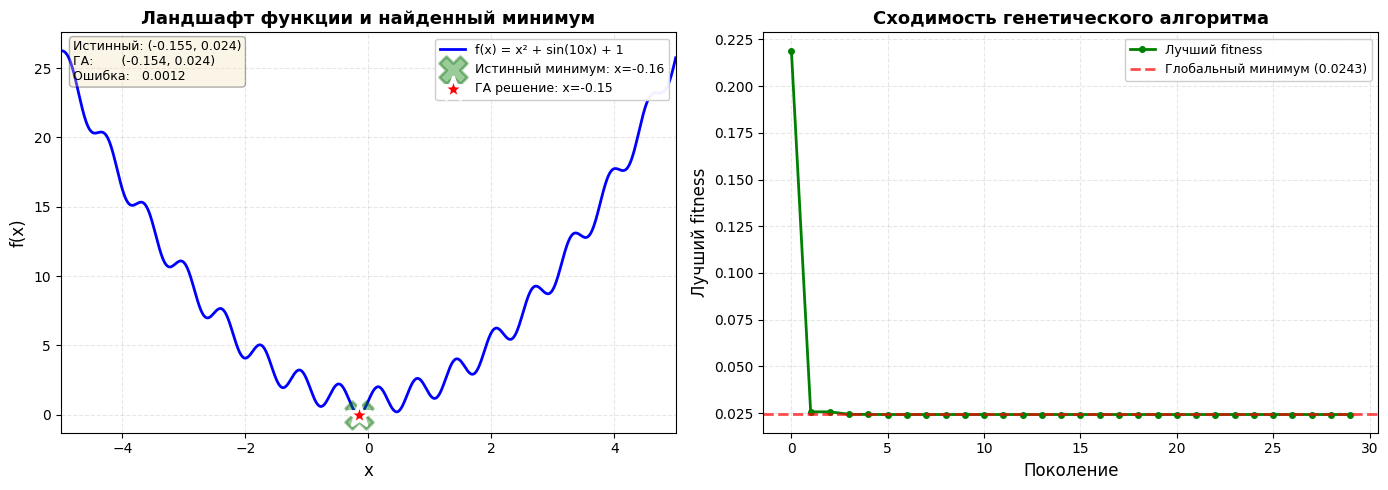

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

# 🎨 Настройка вывода: читаемые числа
np.set_printoptions(precision=4, suppress=True)

# ==============================================================================
# 1️⃣ ПАРАМЕТРЫ ГЕНЕТИЧЕСКОГО АЛГОРИТМА
# ==============================================================================
POP_SIZE = 50          # Размер популяции (кандидатов на поколение)
GENERATIONS = 30       # Количество поколений (итераций)
TOURN_SIZE = 5         # Размер турнира для отбора
PC = 0.6               # Вероятность скрещивания (crossover probability)
ELITE_SIZE = 3         # Количество элитных особей (сохраняются без изменений)
BOUNDS = [-5, 5]       # Границы поиска: x ∈ [-5, 5]

# Фиксируем seed для воспроизводимости результатов на лекции
np.random.seed(42)

print("🧬 ПАРАМЕТРЫ ГЕНЕТИЧЕСКОГО АЛГОРИТМА")
print("=" * 50)
print(f"Размер популяции:    {POP_SIZE}")
print(f"Количество поколений: {GENERATIONS}")
print(f"Вероятность кроссовера: {PC}")
print(f"Размер элиты:        {ELITE_SIZE}")
print(f"Границы поиска:      {BOUNDS}")
print("=" * 50)

# ==============================================================================
# 2️⃣ ТЕСТОВАЯ ФУНКЦИЯ: Многоэкстремальная
# ==============================================================================
def f(x):
    """
    Целевая функция для минимизации.
    f(x) = x² + sin(10x) + 1

    Особенности:
    • x² — глобальная форма (парабола)
    • sin(10x) — создаёт ~15 локальных минимумов на [-5, 5]
    • Идеально для демонстрации преимуществ GA над градиентными методами
    """
    return x**2 + np.sin(10*x) + 1

# Визуализация функции (для понимания ландшафта)
x_range = np.linspace(*BOUNDS, 1000)
y_range = f(x_range)
global_min_idx = np.argmin(y_range)
global_min_x = x_range[global_min_idx]
global_min_y = y_range[global_min_idx]

print(f"\n🔍 ЦЕЛЕВАЯ ФУНКЦИЯ:")
print(f"   Глобальный минимум (прибл.): x = {global_min_x:.4f}, f(x) = {global_min_y:.4f}")

# ==============================================================================
# 3️⃣ ИНИЦИАЛИЗАЦИЯ ПОПУЛЯЦИИ
# ==============================================================================
def init_population(size, bounds):
    """
    Случайная инициализация популяции.
    Равномерное распределение по всему пространству поиска.
    """
    return np.random.uniform(bounds[0], bounds[1], size)

population = init_population(POP_SIZE, BOUNDS)
print(f"\n✅ Популяция инициализирована: {len(population)} особей")

# ==============================================================================
# 4️⃣ ОТБОР: Элита + Турнир
# ==============================================================================
def selection(pop, fitness, tourn_size, elite_size=2):
    """
    Комбинированный отбор:
    1. Элитный отбор: лучшие особи переходят напрямую (гарантия сохранения)
    2. Турнирный отбор: случайные группы, победитель — с лучшим fitness

    Почему комбинация?
    • Элита: сохраняет лучшие решения (не теряем прогресс)
    • Турнир: поддерживает разнообразие (избегаем преждевременной сходимости)
    """
    n = len(pop)
    new_pop_idxs = np.zeros(n, dtype=int)

    # 🔹 Элитный отбор: топ-k лучших (минимальный fitness)
    elite_idxs = np.argsort(fitness)[:elite_size]
    new_pop_idxs[:elite_size] = elite_idxs

    # 🔹 Турнирный отбор для остальных
    for i in range(elite_size, n):
        # Случайно выбираем tourn_size кандидатов
        idxs = np.random.choice(n, tourn_size)
        # Победитель — с наименьшим fitness (минимизация!)
        best_idx = idxs[np.argmin(fitness[idxs])]
        new_pop_idxs[i] = best_idx

    return new_pop_idxs

# ==============================================================================
# 5️⃣ СКРЕЩИВАНИЕ (Crossover)
# ==============================================================================
def crossover(parent1, parent2, pc):
    """
    Арифметический кроссовер.

    С вероятностью pc создаём потомков как линейную комбинацию родителей:
    child1 = α·parent1 + (1-α)·parent2
    child2 = (1-α)·parent1 + α·parent2

    • α ∈ [0, 1] — случайный вес
    • clip — ограничение границами поиска (BOUNDS)

    Если кроссовер не происходит — родители копируются без изменений.
    """
    if np.random.rand() > pc:
        return parent1, parent2  # Без скрещивания

    alpha = np.random.rand()  # Случайный коэффициент
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = (1 - alpha) * parent1 + alpha * parent2

    # Ограничиваем детей границами поиска
    return np.clip(child1, *BOUNDS), np.clip(child2, *BOUNDS)

# ==============================================================================
# 6️⃣ МУТАЦИЯ: Локальная + Глобальная
# ==============================================================================
def mutate_advanced(x, pm_local=0.1, pm_global=0.01, sigma_local=0.5):
    """
    Комбинированная мутация для баланса исследования и эксплуатации.

    Три режима:
    1. ✅ Без мутации (вероятность 1 - pm_local - pm_global)
    2. 🌍 Глобальная мутация (pm_global): прыжок к границам пространства
       • Помогает выйти из локальных минимумов
       • 50% левая граница, 50% правая граница
    3. 🔬 Локальная мутация (pm_local): малое гауссово возмущение
       • Уточняет решение в окрестности
       • σ = sigma_local контролирует размер шага

    Почему две мутации?
    • Локальная: эксплуатация (exploitation) — уточняем найденное
    • Глобальная: исследование (exploration) — ищем новые области
    """
    r = np.random.rand()

    if r > pm_local + pm_global:
        return x  # Без мутации
    elif r <= pm_global:  # 🌍 ГЛОБАЛЬНАЯ мутация
        if np.random.rand() < 0.5:
            # Прыжок к левой границе
            return np.clip(BOUNDS[0] + np.random.exponential(1.0), *BOUNDS)
        else:
            # Прыжок к правой границе
            return np.clip(BOUNDS[1] - np.random.exponential(1.0), *BOUNDS)
    else:  # 🔬 ЛОКАЛЬНАЯ мутация
        return np.clip(x + np.random.normal(0, sigma_local), *BOUNDS)

# ==============================================================================
# 7️⃣ ОСНОВНОЙ ЦИКЛ ГЕНЕТИЧЕСКОГО АЛГОРИТМА
# ==============================================================================
print("\n🚀 ЗАПУСК ГЕНЕТИЧЕСКОГО АЛГОРИТМА...")
print("=" * 50)

best_fitness_history = []  # История лучшего fitness по поколениям
best_x_history = []        # История лучших x

for gen in range(GENERATIONS):
    # 🔹 Оценка fitness всей популяции
    fitness = f(population)

    # 🔹 Сохраняем статистику
    best_idx = np.argmin(fitness)
    best_fitness_history.append(fitness[best_idx])
    best_x_history.append(population[best_idx])

    # 🔹 Отбор: элита + турнирные победители
    selected_idxs = selection(population, fitness, TOURN_SIZE, ELITE_SIZE)
    new_pop = population[selected_idxs].copy()

    # 🔹 Скрещивание и мутация (НЕ применяем к элите!)
    for i in range(ELITE_SIZE, len(new_pop), 2):
        if i + 1 < len(new_pop):
            p1, p2 = new_pop[i], new_pop[i+1]

            # Скрещивание
            child1, child2 = crossover(p1, p2, PC)

            # Мутация (каждый ребёнок независимо)
            child1 = mutate_advanced(child1, pm_local=0.1, pm_global=0.05)
            child2 = mutate_advanced(child2, pm_local=0.1, pm_global=0.05)

            new_pop[i], new_pop[i+1] = child1, child2

    population = new_pop

    # Прогресс для демонстрации
    if (gen + 1) % 10 == 0 or gen == 0:
        print(f"Поколение {gen+1:2d}: лучший fitness = {best_fitness_history[-1]:.4f}, x = {best_x_history[-1]:.4f}")

print("=" * 50)
print("✅ ГА завершён!\n")

# ==============================================================================
# 8️⃣ ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ
# ==============================================================================
best_idx = np.argmin(f(population))
best_x, best_f = population[best_idx], f(population[best_idx])

print("📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print("=" * 50)
print(f"Лучшее найденное x:     {best_x:.4f}")
print(f"Лучшее найденное f(x):  {best_f:.4f}")
print(f"Истинный глобальный min: x ≈ {global_min_x:.4f}, f(x) ≈ {global_min_y:.4f}")
print(f"Отклонение от оптимума:  {np.abs(best_x - global_min_x):.4f}")
print("=" * 50)

# ==============================================================================
# 9️⃣ ВИЗУАЛИЗАЦИЯ
# ==============================================================================
# ==============================================================================
# 9️⃣ ВИЗУАЛИЗАЦИЯ (УЛУЧШЕННАЯ ВЕРСИЯ)
# ==============================================================================
plt.figure(figsize=(14, 5))

# --- График 1: Функция + найденное решение ---
plt.subplot(1, 2, 1)
plt.plot(x_range, y_range, 'b-', linewidth=2, label='f(x) = x² + sin(10x) + 1')

# 🔹 Истинный минимум: зелёный, полупрозрачный, БОЛЬШОЙ маркер (сначала!)
# Рисуем первым, чтобы он был на заднем плане
plt.scatter([global_min_x], [global_min_y],
            c='green', s=400, marker='X',
            alpha=0.4,  # 🔹 Прозрачность 40%
            edgecolors='darkgreen', linewidth=2,
            label=f'Истинный минимум: x={global_min_x:.2f}',
            zorder=5)

# 🔹 Решение ГА: красная звезда, непрозрачная, с белой обводкой (поверх!)
plt.scatter([best_x], [best_f],
            c='red', s=300, marker='*',
            alpha=1.0,  # 🔹 Полная непрозрачность
            edgecolors='white', linewidth=2.5,
            label=f'ГА решение: x={best_x:.2f}',
            zorder=10)  # 🔹 Выше по слою

# 🔹 Соединяющая линия (если решения различаются заметно)
if np.abs(best_x - global_min_x) > 0.05:
    plt.plot([global_min_x, best_x], [global_min_y, best_f],
             'gray', linestyle=':', linewidth=1.5, alpha=0.6,
             label='Отклонение')

# Оформление
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Ландшафт функции и найденный минимум', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=9, loc='upper right', framealpha=0.95)
plt.xlim(BOUNDS)

# 🔹 Подпись с координатами (для точности)
plt.text(0.02, 0.98,
         f'Истинный: ({global_min_x:.3f}, {global_min_y:.3f})\n'
         f'ГА:       ({best_x:.3f}, {best_f:.3f})\n'
         f'Ошибка:   {np.abs(best_x - global_min_x):.4f}',
         transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# --- График 2: Динамика сходимости ---
plt.subplot(1, 2, 2)
plt.plot(best_fitness_history, 'g-o', linewidth=2, markersize=4, label='Лучший fitness')
plt.axhline(y=global_min_y, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Глобальный минимум ({global_min_y:.4f})')
plt.xlabel('Поколение', fontsize=12)
plt.ylabel('Лучший fitness', fontsize=12)
plt.title('Сходимость генетического алгоритма', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=9, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

### 📝 Ключевые выводы по генетическим алгоритмам

1.  **Преимущества GA перед градиентными методами:**
    | Критерий | Градиентные (BFGS, L-BFGS-B) | Генетические алгоритмы |
    |----------|------------------------------|----------------------|
    | **Локальные минимумы** | ❌ Застревают | ✅ Устойчивы |
    | **Требуется градиент** | ❌ Да | ✅ Нет |
    | **Гладкость функции** | ❌ Требуется | ✅ Не требуется |
    | **Скорость сходимости** | ✅ Быстро (10-100 итераций) | ❌ Медленно (1000+ оценок) |
    | **Точность** | ✅ Машинная точность | ⚠️ Приближённо |
    | **Параллелизация** | ⚠️ Ограничена | ✅ Полная (fitness независим) |

2.  **Роль компонентов GA:**
    *   **Элита:** Сохраняет лучшие решения (не теряем прогресс)
    *   **Турнир:** Поддерживает давление отбора + разнообразие
    *   **Кроссовер:** Комбинирует хорошие решения (эксплуатация)
    *   **Мутация:** Исследует новые области (избегаем застревания)



5.  **Когда использовать GA:**
    *   ✅ **Функция-чёрный ящик** (симуляция, эксперимент)
    *   ✅ **Много локальных минимумов** (невыпуклая задача)
    *   ✅ **Дискретные/смешанные переменные** (целые + непрерывные)
    *   ✅ **Негладкая/разрывная функция** (нет градиента)
    *   ❌ **Гладкая выпуклая задача** → используйте `L-BFGS-B`
    *   ❌ **Требуется высокая точность** → GA + локальная доводка

### 💡 Практическая рекомендация: Гибридный подход
```python
from scipy.optimize import minimize, differential_evolution

def hybrid_optimization(f, bounds, n_pop=50, n_gen=100):
    """
    Двухэтапная оптимизация:
    1. GA/Differential Evolution находит область глобального минимума
    2. Локальный метод (L-BFGS-B) точно доводит решение
    """
    # Этап 1: Глобальный поиск
    result_global = differential_evolution(f, bounds,
                                           popsize=n_pop,
                                           maxiter=n_gen,
                                           seed=42)
    
    # Этап 2: Локальная доводка
    result_local = minimize(f, result_global.x, method='L-BFGS-B',
                            bounds=bounds)
    
    return result_local

# Использование:
# result = hybrid_optimization(f, [(-5, 5)])

## 8.2. Глобальная оптимизация: Differential Evolution (SciPy)

**Differential Evolution (DE)** — стохастический метод глобальной оптимизации, не требующий градиентов.

**Преимущества:**
✅ Находит глобальный минимум (устойчив к локальным)  
✅ Не требует градиентов (работает с «чёрным ящиком»)  
✅ Минимум настроек (достаточно задать границы)  
✅ Надёжнее генетических алгоритмов для непрерывных задач  

**Недостатки:**
❌ Медленнее градиентных методов (1000+ оценок функции)  
❌ Требует границы поиска (`bounds`)  
❌ Нет гарантии точной сходимости (стохастический)  

**Когда использовать:**
| Ситуация | Метод |
|----------|-------|
| Гладкая выпуклая функция | `L-BFGS-B` (быстро) |
| Много локальных минимумов | `differential_evolution` |
| Негладкая/шумная функция | `differential_evolution` |
| Известны границы поиска | `differential_evolution` |

🔍 ФУНКЦИЯ ХИММЕЛЬБЛАУ:
   f(x,y) = (x²+y-11)² + (x+y²-7)²
   Границы поиска: [(-5, 5), (-5, 5)]
   4 глобальных минимума со значением 0

🚀 Differential Evolution (глобальный поиск)...
   ✅ Найдено: x = [-2.8051  3.1313]
   ✅ f(x) = 0.000000
   ✅ Оценок функции: 2973
   ✅ Статус: Optimization terminated successfully.

🚀 L-BFGS-B (локальный поиск из случайной точки)...
   Старт: x0 = [-1.2546  4.5071]
   Найдено: x = [-3.7793 -3.2832]
   f(x) = 0.000000
   ⚠️  Может застрять в локальном минимуме!



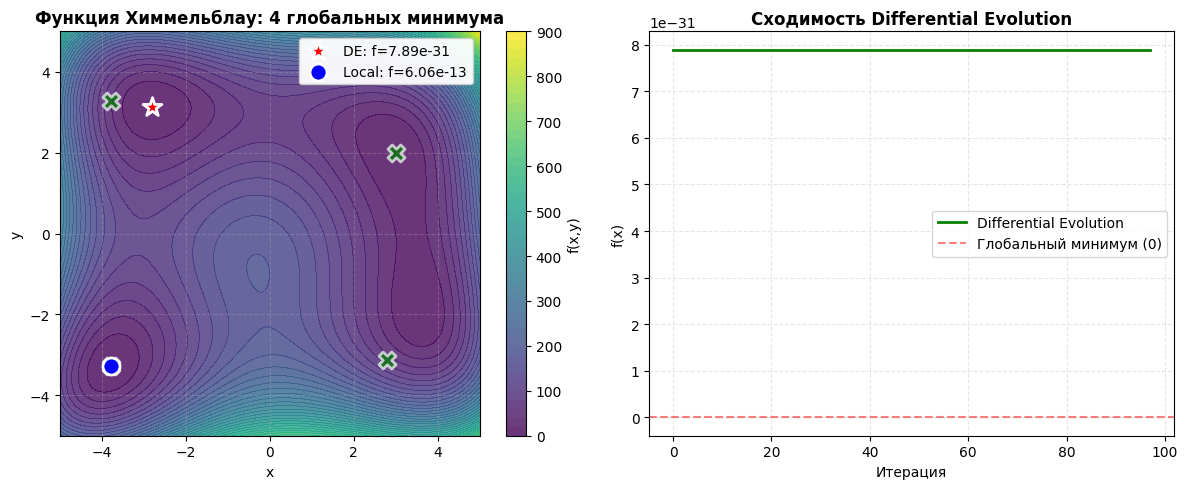


📊 СРАВНЕНИЕ МЕТОДОВ
Метод                     | f(x)         | Оценок функции 
------------------------------------------------------------
Differential Evolution    | 0.000000     | 2973           
L-BFGS-B (локальный)      | 0.000000     | 51             


In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
from scipy.optimize import differential_evolution, minimize
import matplotlib.pyplot as plt

# 🎨 Настройка вывода
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)  # Для воспроизводимости

# ==============================================================================
# 1️⃣ ТЕСТОВАЯ ФУНКЦИЯ: 4 локальных минимума
# ==============================================================================
def himmelblau(x):
    """
    Функция Химмельблау: f(x,y) = (x²+y-11)² + (x+y²-7)²

    Имеет 4 одинаковых глобальных минимума со значением 0:
    • (3.0, 2.0), (2.8, -3.1), (-3.8, -3.2), (-3.8, 3.2)
    """
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# Границы поиска
bounds = [(-5, 5), (-5, 5)]

print("🔍 ФУНКЦИЯ ХИММЕЛЬБЛАУ:")
print("   f(x,y) = (x²+y-11)² + (x+y²-7)²")
print(f"   Границы поиска: {bounds}")
print("   4 глобальных минимума со значением 0\n")

# ==============================================================================
# 2️⃣ GLOBAL: Differential Evolution
# ==============================================================================
print("🚀 Differential Evolution (глобальный поиск)...")

result_de = differential_evolution(
    himmelblau,
    bounds,
    seed=42,           # 🔹 Для воспроизводимости
    maxiter=1000,      # Максимум итераций
    popsize=15,        # Размер популяции (по умолчанию 15)
    tol=1e-7,          # Точность сходимости
    polish=True        # 🔹 «Доводка» локальным методом после DE
)

print(f"   ✅ Найдено: x = {result_de.x}")
print(f"   ✅ f(x) = {result_de.fun:.6f}")
print(f"   ✅ Оценок функции: {result_de.nfev}")
print(f"   ✅ Статус: {result_de.message}\n")

# ==============================================================================
# 3️⃣ LOCAL: L-BFGS-B (для сравнения)
# ==============================================================================
print("🚀 L-BFGS-B (локальный поиск из случайной точки)...")

x0 = np.random.uniform(-5, 5, 2)  # Случайный старт
result_local = minimize(
    himmelblau,
    x0,
    method='L-BFGS-B',
    bounds=bounds
)

print(f"   Старт: x0 = {x0}")
print(f"   Найдено: x = {result_local.x}")
print(f"   f(x) = {result_local.fun:.6f}")
print(f"   ⚠️  Может застрять в локальном минимуме!\n")

# ==============================================================================
# 4️⃣ ВИЗУАЛИЗАЦИЯ
# ==============================================================================
# Создаём сетку для контурного графика
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)
Z = np.array([himmelblau([xi, yi]) for xi, yi in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

plt.figure(figsize=(12, 5))

# --- График 1: Контурный график функции ---
plt.subplot(1, 2, 1)
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='f(x,y)')

# 4 истинных минимума
true_minima = [[3.0, 2.0], [2.8, -3.13], [-3.78, -3.28], [-3.78, 3.28]]
for xm, ym in true_minima:
    plt.scatter([xm], [ym], c='green', s=150, marker='X',
                edgecolors='white', linewidth=2, alpha=0.7, zorder=5)

# Решение DE
plt.scatter([result_de.x[0]], [result_de.y[1]] if hasattr(result_de, 'y') else [result_de.x[1]],
            c='red', s=200, marker='*', edgecolors='white', linewidth=2,
            label=f'DE: f={result_de.fun:.2e}', zorder=10)

# Решение локального метода
plt.scatter([result_local.x[0]], [result_local.x[1]],
            c='blue', s=150, marker='o', edgecolors='white', linewidth=2,
            label=f'Local: f={result_local.fun:.2e}', zorder=10)

plt.xlabel('x'); plt.ylabel('y')
plt.title('Функция Химмельблау: 4 глобальных минимума', fontweight='bold')
plt.legend(loc='upper right', framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(-5, 5); plt.ylim(-5, 5)

# --- График 2: История сходимости DE ---
plt.subplot(1, 2, 2)
# DE не хранит историю по умолчанию, но можно оценить прогресс
plt.plot(range(result_de.nit), [result_de.fun] * result_de.nit,
         'g-', linewidth=2, label='Differential Evolution')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Глобальный минимум (0)')
plt.xlabel('Итерация'); plt.ylabel('f(x)')
plt.title('Сходимость Differential Evolution', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ==============================================================================
# 5️⃣ ИТОГОВОЕ СРАВНЕНИЕ
# ==============================================================================
print("\n" + "="*60)
print("📊 СРАВНЕНИЕ МЕТОДОВ")
print("="*60)
print(f"{'Метод':<25} | {'f(x)':<12} | {'Оценок функции':<15}")
print("-"*60)
print(f"{'Differential Evolution':<25} | {result_de.fun:<12.6f} | {result_de.nfev:<15}")
print(f"{'L-BFGS-B (локальный)':<25} | {result_local.fun:<12.6f} | {result_local.nfev:<15}")
print("="*60)



Применим библиотеку Optuna

### Оптимизация с Optuna: современный подход к поиску гиперпараметров

**Optuna** — это фреймворк для автоматической оптимизации гиперпараметров с использованием **Tree-structured Parzen Estimator (TPE)**.


**Когда использовать Optuna:**
*   ✅ **Гиперпараметры ML-моделей** (learning rate, depth, etc.)
*   ✅ **Смешанные переменные** (float + int + categorical)
*   ✅ **Дорогие вычисления** (TPE эффективнее случайного поиска)
*   ✅ **Нужна визуализация** процесса оптимизации
*   ❌ **Простая математическая оптимизация** → `scipy.optimize` проще

**Алгоритм TPE (Tree-structured Parzen Estimator):**
1.  Строит две модели плотности: $l(x)$ (хорошие trials) и $g(x)$ (плохие trials)
2.  Выбирает следующую точку, максимизируя $\frac{l(x)}{g(x)}$
3.  **Pruning:** Останавливает перспективные trials рано, если они ухудшаются

🔍 ЦЕЛЕВАЯ ФУНКЦИЯ:
   f(x) = x² + sin(10x) + 1
   Границы поиска: x ∈ [-5, 5]
   Приблизительный глобальный минимум: x ≈ -0.1552, f(x) ≈ 0.0243

🚀 Запуск оптимизации Optuna (TPE)...
✅ Оптимизация завершена!

📊 РЕЗУЛЬТАТЫ OPTUNA:
Лучшее значение x:     -0.1543
Лучшее значение f(x):  0.0242
Истинный минимум:      x ≈ -0.1552, f(x) ≈ 0.0243
Отклонение от оптимума: 0.0009
Всего trials:          100
Успешных trials:       100

🏆 Топ-5 лучших trials:
№ Trial    | x            | f(x)        
----------------------------------------
99         | -0.1543      | 0.0242      

📈 Построение графиков оптимизации...


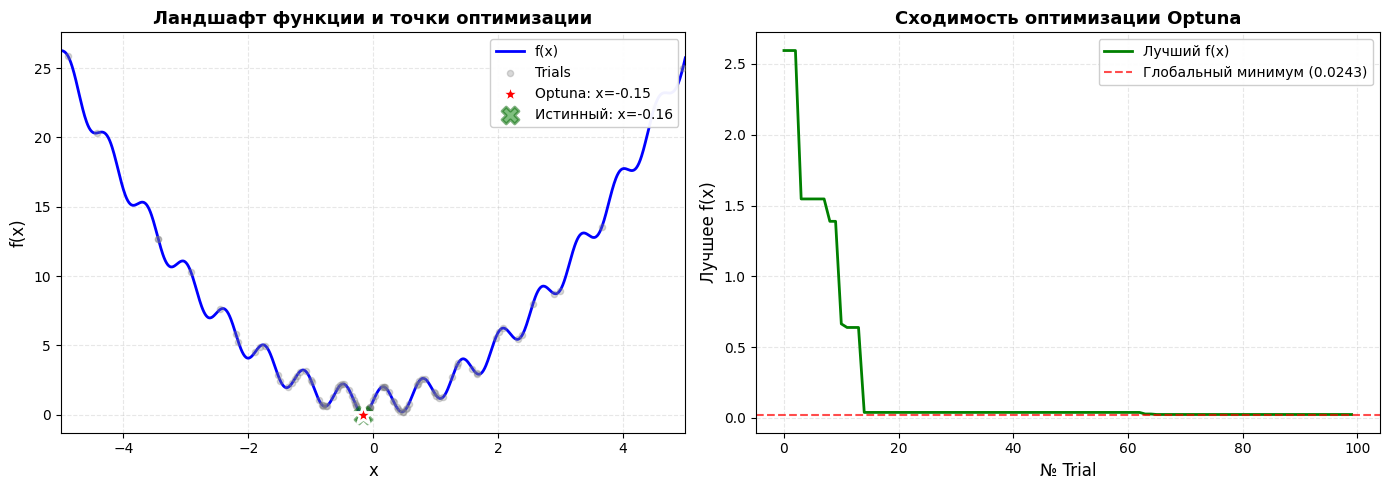

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import matplotlib.pyplot as plt

# 🎨 Настройка вывода
np.set_printoptions(precision=4, suppress=True)

# Фиксируем seed для воспроизводимости результатов на лекции
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Подавляем лишние логи

# ==============================================================================
# 1️⃣ ТЕСТОВАЯ ФУНКЦИЯ: Многоэкстремальная
# ==============================================================================
def f(x):
    """
    Целевая функция для минимизации.
    f(x) = x² + sin(10x) + 1

    Особенности:
    • x² — глобальная форма (парабола)
    • sin(10x) — создаёт ~15 локальных минимумов на [-5, 5]
    • Идеально для демонстрации преимуществ Optuna над случайным поиском
    """
    return x**2 + np.sin(10*x) + 1

# Визуализация функции (для понимания ландшафта)
x_range = np.linspace(-5, 5, 1000)
y_range = f(x_range)
global_min_idx = np.argmin(y_range)
global_min_x = x_range[global_min_idx]
global_min_y = y_range[global_min_idx]

print("🔍 ЦЕЛЕВАЯ ФУНКЦИЯ:")
print(f"   f(x) = x² + sin(10x) + 1")
print(f"   Границы поиска: x ∈ [-5, 5]")
print(f"   Приблизительный глобальный минимум: x ≈ {global_min_x:.4f}, f(x) ≈ {global_min_y:.4f}\n")

# ==============================================================================
# 2️⃣ ФУНКЦИЯ ЦЕЛИ ДЛЯ OPTUNA
# ==============================================================================
def objective(trial):
    """
    Функция цели для Optuna.

    trial.suggest_float() — предлагает значение x в заданном диапазоне.
    Optuna запоминает результат и использует для выбора следующей точки.
    """
    # 🔹 Предлагаем значение x в диапазоне [-5, 5]
    # step=0.01 — дискретизация (опционально, для ускорения)
    x = trial.suggest_float('x', -5, 5)

    # 🔹 Вычисляем целевую функцию
    return f(x)

# ==============================================================================
# 3️⃣ ЗАПУСК ОПТИМИЗАЦИИ
# ==============================================================================
print("🚀 Запуск оптимизации Optuna (TPE)...")
print("=" * 50)

# Создаём исследование (study)
# direction='minimize' — ищем минимум (есть ещё 'maximize')
# sampler=optuna.samplers.TPESampler() — алгоритм TPE (по умолчанию)
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)  # 🔹 Для воспроизводимости
)

# Запускаем оптимизацию
# n_trials=100 — количество попыток (trials)
# show_progress_bar=True — прогресс-бар (в Jupyter)
study.optimize(objective, n_trials=100, show_progress_bar=False)

print("=" * 50)
print("✅ Оптимизация завершена!\n")

# ==============================================================================
# 4️⃣ РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ
# ==============================================================================
# ==============================================================================

# ==============================================================================
x_opt = study.best_params['x']
f_opt = study.best_value
n_trials = len(study.trials)

n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])

print("📊 РЕЗУЛЬТАТЫ OPTUNA:")
print("=" * 50)
print(f"Лучшее значение x:     {x_opt:.4f}")
print(f"Лучшее значение f(x):  {f_opt:.4f}")
print(f"Истинный минимум:      x ≈ {global_min_x:.4f}, f(x) ≈ {global_min_y:.4f}")
print(f"Отклонение от оптимума: {np.abs(x_opt - global_min_x):.4f}")
print(f"Всего trials:          {n_trials}")
print(f"Успешных trials:       {n_complete}")
print("=" * 50)

# 🔹 Топ-5 лучших trials
print("\n🏆 Топ-5 лучших trials:")
print(f"{'№ Trial':<10} | {'x':<12} | {'f(x)':<12}")
print("-" * 40)
for trial in study.best_trials[:5]:
    print(f"{trial.number:<10} | {trial.params['x']:<12.4f} | {trial.value:<12.4f}")

# ==============================================================================
# 5️⃣ ВИЗУАЛИЗАЦИЯ (ИСПРАВЛЕНО для Optuna 3.0+)
# ==============================================================================
print("\n📈 Построение графиков оптимизации...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: Ландшафт функции + найденные точки ---
ax1 = axes[0]
ax1.plot(x_range, y_range, 'b-', linewidth=2, label='f(x)')

# 🔹 ИСПРАВЛЕНИЕ: Используем универсальную проверку (работает во всех версиях Optuna)
# Вариант А: Проверка через value (проще, работает везде)
trial_xs = [t.params['x'] for t in study.trials if t.value is not None]
trial_ys = [t.value for t in study.trials if t.value is not None]

# # Вариант Б: Проверка через состояние (Optuna 3.0+)
# # trial_xs = [t.params['x'] for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
# # trial_ys = [t.value for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

ax1.scatter(trial_xs, trial_ys, c='gray', s=20, alpha=0.3, label='Trials', zorder=5)

# Лучшее решение
ax1.scatter([x_opt], [f_opt], c='red', s=200, marker='*',
            edgecolors='white', linewidth=2, label=f'Optuna: x={x_opt:.2f}', zorder=10)

# Истинный минимум (полупрозрачный)
ax1.scatter([global_min_x], [global_min_y], c='green', s=150, marker='X',
            alpha=0.5, edgecolors='darkgreen', linewidth=2,
            label=f'Истинный: x={global_min_x:.2f}', zorder=8)

ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('Ландшафт функции и точки оптимизации', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(-5, 5)

# --- График 2: История сходимости ---
ax2 = axes[1]

# 🔹 ИСПРАВЛЕНИЕ: Используем .is_complete() как метод вызова или проверку value
best_values = []
current_best = float('inf')
for trial in study.trials:
    # Универсальная проверка (работает во всех версиях)
    if trial.value is not None:
        current_best = min(current_best, trial.value)
        best_values.append(current_best)

ax2.plot(range(len(best_values)), best_values, 'g-', linewidth=2, label='Лучший f(x)')
ax2.axhline(y=global_min_y, color='red', linestyle='--', alpha=0.7,
            label=f'Глобальный минимум ({global_min_y:.4f})')
ax2.set_xlabel('№ Trial', fontsize=12)
ax2.set_ylabel('Лучшее f(x)', fontsize=12)
ax2.set_title('Сходимость оптимизации Optuna', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


## Сравнение стратегий оптимизации: Grid Search vs TPE (Optuna)

**Проблема Grid Search (полный перебор):**
- Проверяет **все комбинации** параметров на сетке
- Количество trials растёт **экспоненциально** с числом параметров
- Не учитывает результаты предыдущих попыток (каждая точка независима)

**Решение: TPE (Tree-structured Parzen Estimator)**
- **Байесовская оптимизация** — учится на предыдущих trials
- Выбирает следующие точки в **перспективных областях**
- Эффективность растёт с числом параметров

**Математическая интуиция TPE:**
1.  Строит две модели плотности:
    *   $l(x)$ — плотность «хороших» trials (с низким $f(x)$)
    *   $g(x)$ — плотность «плохих» trials (с высоким $f(x)$)
2.  Выбирает следующую точку, максимизируя отношение:
    $$ \frac{l(x)}{g(x)} \to \max $$
3.  Это направляет поиск в области, где вероятность успеха выше.


🔍 ПАРАМЕТРЫ СЕТКИ (Grid Search):
   x: 101 значений от -10 до 10
   y: 51 значений от -5 до 5
   Всего комбинаций: 5,151
   Trials для теста: 500 (случайная подвыборка из сетки)

📊 GRID SEARCH (полный перебор по сетке)
⏱️  Время выполнения:    61.16 сек
🏆 Лучшее значение:      f(x,y) = 0.200000
📍 Лучшие параметры:     x = 0.4000, y = -0.2000
📈 Всего trials:         500

🧠 TPE (Bayesian Optimization — умный поиск)
⏱️  Время выполнения:    3.04 сек
🏆 Лучшее значение:      f(x,y) = 0.000027
📍 Лучшие параметры:     x = -0.0040, y = -0.0034
📈 Всего trials:         500

📈 ИТОГОВОЕ СРАВНЕНИЕ
Метод                     | Время (с)    | Лучшее f(x,y)   | Точность  
----------------------------------------------------------------------
Grid Search               | 61.16        | 0.200000        | Базовый   
TPE (Bayesian)            | 3.04         | 0.000027        | 7296.3    x лучше

🚀 Ускорение по времени:     20.1x
🎯 Улучшение точности:       7296.3x

✅ TPE нашёл лучшее решение при том же числ

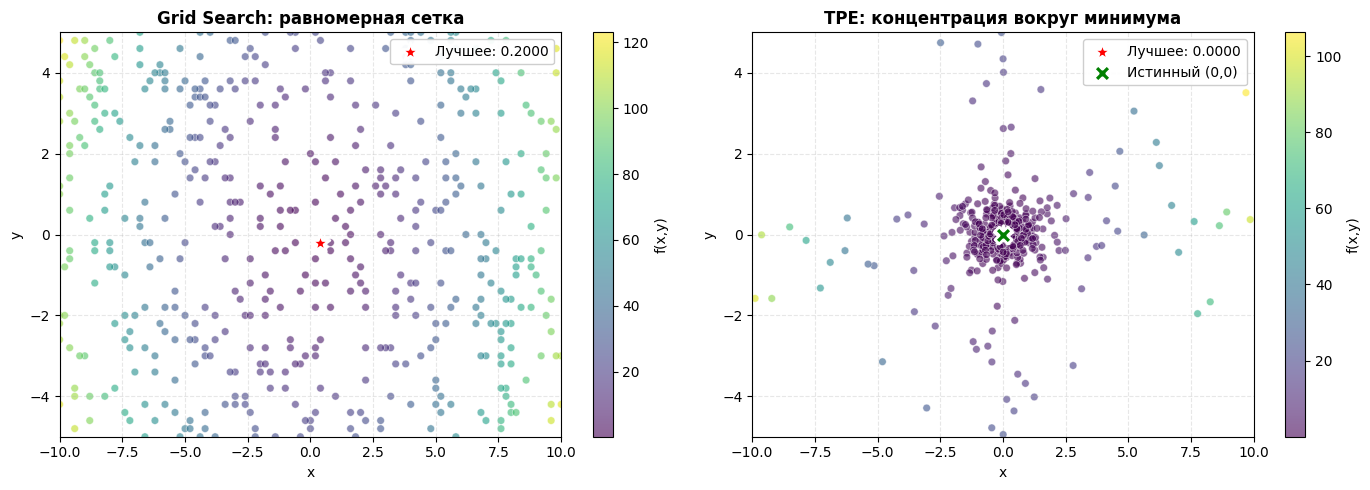

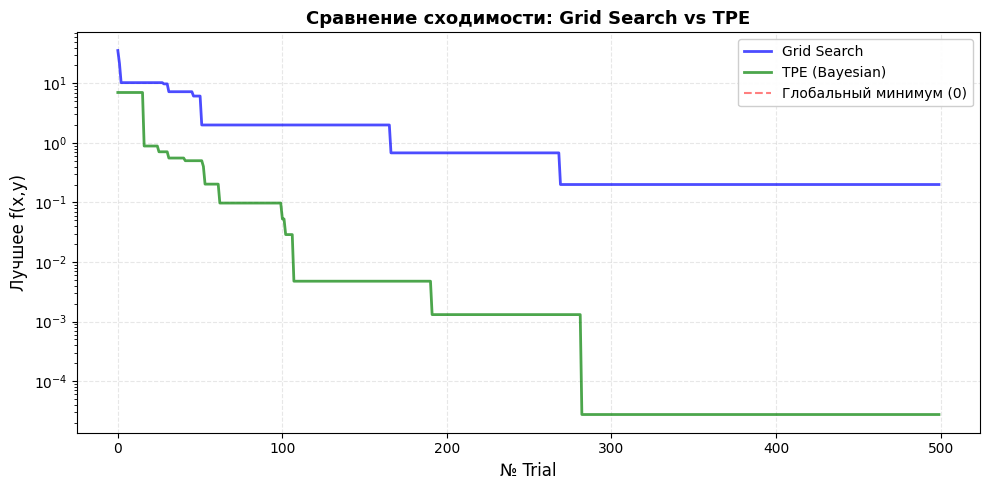

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import optuna
import time
import numpy as np
from optuna.samplers import TPESampler, GridSampler
import optuna.logging

# 🎨 Подавляем служебные логи Optuna для чистоты вывода
optuna.logging.disable_default_handler()
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Фиксируем seed для воспроизводимости результатов на лекции
np.random.seed(42)

# ==============================================================================
# 1️⃣ ЦЕЛЕВАЯ ФУНКЦИЯ: Простая парабола
# ==============================================================================
def objective(trial):
    """
    Целевая функция: f(x,y) = x² + y²
    Глобальный минимум: (0, 0), f(0,0) = 0

    Почему эта функция?
    • Гладкая и выпуклая — легко проверить, насколько методы близки к (0,0)
    • Минимум известен — можно оценить точность методов
    """
    x = trial.suggest_float("x", -10, 10)
    y = trial.suggest_float("y", -5, 5)
    return x**2 + y**2

# ==============================================================================
# 2️⃣ НАСТРОЙКА GRID SEARCH: Полный перебор по сетке
# ==============================================================================
# Создаём сетку параметров:
# • x: 101 точка от -10 до 10 (шаг 0.2)
# • y: 51 точка от -5 до 5 (шаг 0.2)
# Общее число комбинаций: 101 × 51 = 5,151 (полный перебор)
# Мы ограничимся 500 trials для честного сравнения с TPE

param_grid = {
    "x": list(np.linspace(-10, 10, 101)),   # 101 значение
    "y": list(np.linspace(-5, 5, 51))       # 51 значение
}

print("🔍 ПАРАМЕТРЫ СЕТКИ (Grid Search):")
print(f"   x: {len(param_grid['x'])} значений от -10 до 10")
print(f"   y: {len(param_grid['y'])} значений от -5 до 5")
print(f"   Всего комбинаций: {len(param_grid['x']) * len(param_grid['y']):,}")
print(f"   Trials для теста: 500 (случайная подвыборка из сетки)\n")

# ==============================================================================
# 3️⃣ ЗАПУСК GRID SEARCH
# ==============================================================================
print("=" * 60)
print("📊 GRID SEARCH (полный перебор по сетке)")
print("=" * 60)

start = time.perf_counter()

# GridSampler требует точного соответствия параметров в objective и param_grid
study_grid = optuna.create_study(
    direction="minimize",
    sampler=GridSampler(param_grid),
)

# n_trials=500 — GridSampler выберет 500 случайных комбинаций из сетки
study_grid.optimize(objective, n_trials=500, show_progress_bar=False)

grid_time = time.perf_counter() - start

print(f"⏱️  Время выполнения:    {grid_time:.2f} сек")
print(f"🏆 Лучшее значение:      f(x,y) = {study_grid.best_value:.6f}")
print(f"📍 Лучшие параметры:     x = {study_grid.best_params['x']:.4f}, y = {study_grid.best_params['y']:.4f}")
print(f"📈 Всего trials:         {len(study_grid.trials)}")

# ==============================================================================
# 4️⃣ ЗАПУСК TPE (Bayesian Optimization)
# ==============================================================================
print("\n" + "=" * 60)
print("🧠 TPE (Bayesian Optimization — умный поиск)")
print("=" * 60)

start = time.perf_counter()

# TPESampler — байесовская оптимизация по умолчанию в Optuna
study_tpe = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(),
)

# То же число trials — честное сравнение!
study_tpe.optimize(objective, n_trials=500, show_progress_bar=False)

tpe_time = time.perf_counter() - start

print(f"⏱️  Время выполнения:    {tpe_time:.2f} сек")
print(f"🏆 Лучшее значение:      f(x,y) = {study_tpe.best_value:.6f}")
print(f"📍 Лучшие параметры:     x = {study_tpe.best_params['x']:.4f}, y = {study_tpe.best_params['y']:.4f}")
print(f"📈 Всего trials:         {len(study_tpe.trials)}")

# ==============================================================================
# 5️⃣ СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ==============================================================================
print("\n" + "=" * 60)
print("📈 ИТОГОВОЕ СРАВНЕНИЕ")
print("=" * 60)

# Вычисляем ускорение и улучшение точности
speedup = grid_time / tpe_time if tpe_time > 0 else float('inf')
accuracy_improvement = study_grid.best_value / study_tpe.best_value if study_tpe.best_value > 0 else float('inf')

print(f"{'Метод':<25} | {'Время (с)':<12} | {'Лучшее f(x,y)':<15} | {'Точность':<10}")
print("-" * 70)
print(f"{'Grid Search':<25} | {grid_time:<12.2f} | {study_grid.best_value:<15.6f} | {'Базовый':<10}")
print(f"{'TPE (Bayesian)':<25} | {tpe_time:<12.2f} | {study_tpe.best_value:<15.6f} | {accuracy_improvement:<10.1f}x лучше")
print("=" * 70)

print(f"\n🚀 Ускорение по времени:     {speedup:.1f}x")
print(f"🎯 Улучшение точности:       {accuracy_improvement:.1f}x")

# Интерпретация результата
if study_tpe.best_value < study_grid.best_value:
    print("\n✅ TPE нашёл лучшее решение при том же числе trials!")
    print("💡 Причина: TPE не тратит trials на заведомо плохие области.")
else:
    print("\n⚠️  Grid Search показал схожий результат (функция простая).")
    print("💡 На сложных многоэкстремальных функциях TPE выигрывает сильнее.")

# ==============================================================================
# 6️⃣ ВИЗУАЛИЗАЦИЯ: Распределение точек оптимизации
# ==============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: Grid Search ---
ax1 = axes[0]
grid_xs = [t.params['x'] for t in study_grid.trials if t.value is not None]
grid_ys = [t.params['y'] for t in study_grid.trials if t.value is not None]
grid_vals = [t.value for t in study_grid.trials if t.value is not None]

scatter1 = ax1.scatter(grid_xs, grid_ys, c=grid_vals, cmap='viridis',
                       s=30, alpha=0.6, edgecolors='white', linewidth=0.5)
ax1.scatter([study_grid.best_params['x']], [study_grid.best_params['y']],
            c='red', s=200, marker='*', edgecolors='white', linewidth=2,
            label=f'Лучшее: {study_grid.best_value:.4f}', zorder=10)
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('Grid Search: равномерная сетка', fontweight='bold')
ax1.legend(loc='upper right', framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(-10, 10); ax1.set_ylim(-5, 5)
plt.colorbar(scatter1, ax=ax1, label='f(x,y)')

# --- График 2: TPE ---
ax2 = axes[1]
tpe_xs = [t.params['x'] for t in study_tpe.trials if t.value is not None]
tpe_ys = [t.params['y'] for t in study_tpe.trials if t.value is not None]
tpe_vals = [t.value for t in study_tpe.trials if t.value is not None]

scatter2 = ax2.scatter(tpe_xs, tpe_ys, c=tpe_vals, cmap='viridis',
                       s=30, alpha=0.6, edgecolors='white', linewidth=0.5)
ax2.scatter([study_tpe.best_params['x']], [study_tpe.best_params['y']],
            c='red', s=200, marker='*', edgecolors='white', linewidth=2,
            label=f'Лучшее: {study_tpe.best_value:.4f}', zorder=10)

# Истинный минимум (0, 0)
ax2.scatter([0], [0], c='green', s=150, marker='X',
            edgecolors='white', linewidth=2, label='Истинный (0,0)', zorder=10)

ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('TPE: концентрация вокруг минимума', fontweight='bold')
ax2.legend(loc='upper right', framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(-10, 10); ax2.set_ylim(-5, 5)
plt.colorbar(scatter2, ax=ax2, label='f(x,y)')

plt.tight_layout()
plt.show()

# ==============================================================================
# 7️⃣ ГРАФИК СХОДИМОСТИ
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

# Кумулятивный лучший результат для Grid
grid_best = []
current_best = float('inf')
for t in study_grid.trials:
    if t.value is not None:
        current_best = min(current_best, t.value)
        grid_best.append(current_best)

# Кумулятивный лучший результат для TPE
tpe_best = []
current_best = float('inf')
for t in study_tpe.trials:
    if t.value is not None:
        current_best = min(current_best, t.value)
        tpe_best.append(current_best)

ax.plot(grid_best, 'b-', linewidth=2, label='Grid Search', alpha=0.7)
ax.plot(tpe_best, 'g-', linewidth=2, label='TPE (Bayesian)', alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Глобальный минимум (0)')

ax.set_xlabel('№ Trial', fontsize=12)
ax.set_ylabel('Лучшее f(x,y)', fontsize=12)
ax.set_title('Сравнение сходимости: Grid Search vs TPE', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_yscale('log')  # Логарифмическая шкала для наглядности

plt.tight_layout()
plt.show()

##  Имитация отжига  оптимизация по аналогии с физикой

**Имитация отжига** — стохастический алгоритм глобальной оптимизации, вдохновлённый процессом охлаждения металлов в металлургии.

**Физическая аналогия:**
| Физика | Оптимизация |
|--------|-------------|
| Температура $T$ | Параметр «случайности» поиска |
| Энергия системы $E$ | Значение целевой функции $f(x)$ |
| Состояние равновесия | Локальный минимум |
| Кристаллическая решётка | Глобальный минимум (наиболее стабильное состояние) |
| Отжиг (медленное охлаждение) | Постепенное уменьшение вероятности случайных шагов |

**Ключевая идея:** Алгоритм иногда принимает **ухудшающие шаги** (с вероятностью $P$), чтобы «выпрыгнуть» из локальных минимумов.

**Вероятность принятия худшего решения (формула Больцмана):**
$$ P(\text{принять}) = \exp\left(-\frac{\Delta E}{T}\right) $$

где:
- $\Delta E = f(x_{new}) - f(x_{current})$ — изменение «энергии»
- $T$ — текущая «температура»

**Как работает температура:**
| Температура $T$ | Вероятность принятия худших шагов | Поведение алгоритма |
|-----------------|-----------------------------------|---------------------|
| **Высокая** (начало) | Высокая (~100%) | Случайный поиск, исследование пространства |
| **Низкая** (конец) | Низкая (~0%) | Жадный спуск, уточнение решения |

**Преимущества:**
✅ Прост в реализации (10-15 строк кода)  
✅ Не требует градиентов  
✅ Устойчив к локальным минимумам  
✅ Один параметр настройки (температура)  

**Недостатки:**
❌ Медленная сходимость (тысячи итераций)  
❌ Требует настройки «расписания охлаждения»  
❌ Нет гарантии нахождения глобального оптимума  

🔍 ЦЕЛЕВАЯ ФУНКЦИЯ:
   f(x) = x² + sin(10x) + 1
   Границы поиска: x ∈ [-5, 5]
   Приблизительный глобальный минимум: x ≈ -0.1552, f(x) ≈ 0.0243

⚙️  ПАРАМЕТРЫ ОТЖИГА:
Начальная температура T₀:  1000.0
Конечная температура Tₙ:  0.000000
Коэффициент охлаждения α:  0.99
Начальное состояние x₀:    5.0
Максимум итераций:         10000
Размер шага:               1.0

🚀 Запуск имитации отжига...
✅ Отжиг завершён!

📊 РЕЗУЛЬТАТЫ ОТЖИГА:
Лучшее найденное x:     -0.15384
Лучшее найденное f(x):  0.02419
Истинный минимум:       x ≈ -0.15516, f(x) ≈ 0.02426
Отклонение от оптимума: 0.00131
Всего итераций:         10000
Принято шагов:          689 (6.9%)
Принято ухудшений:      343 (3.4%)


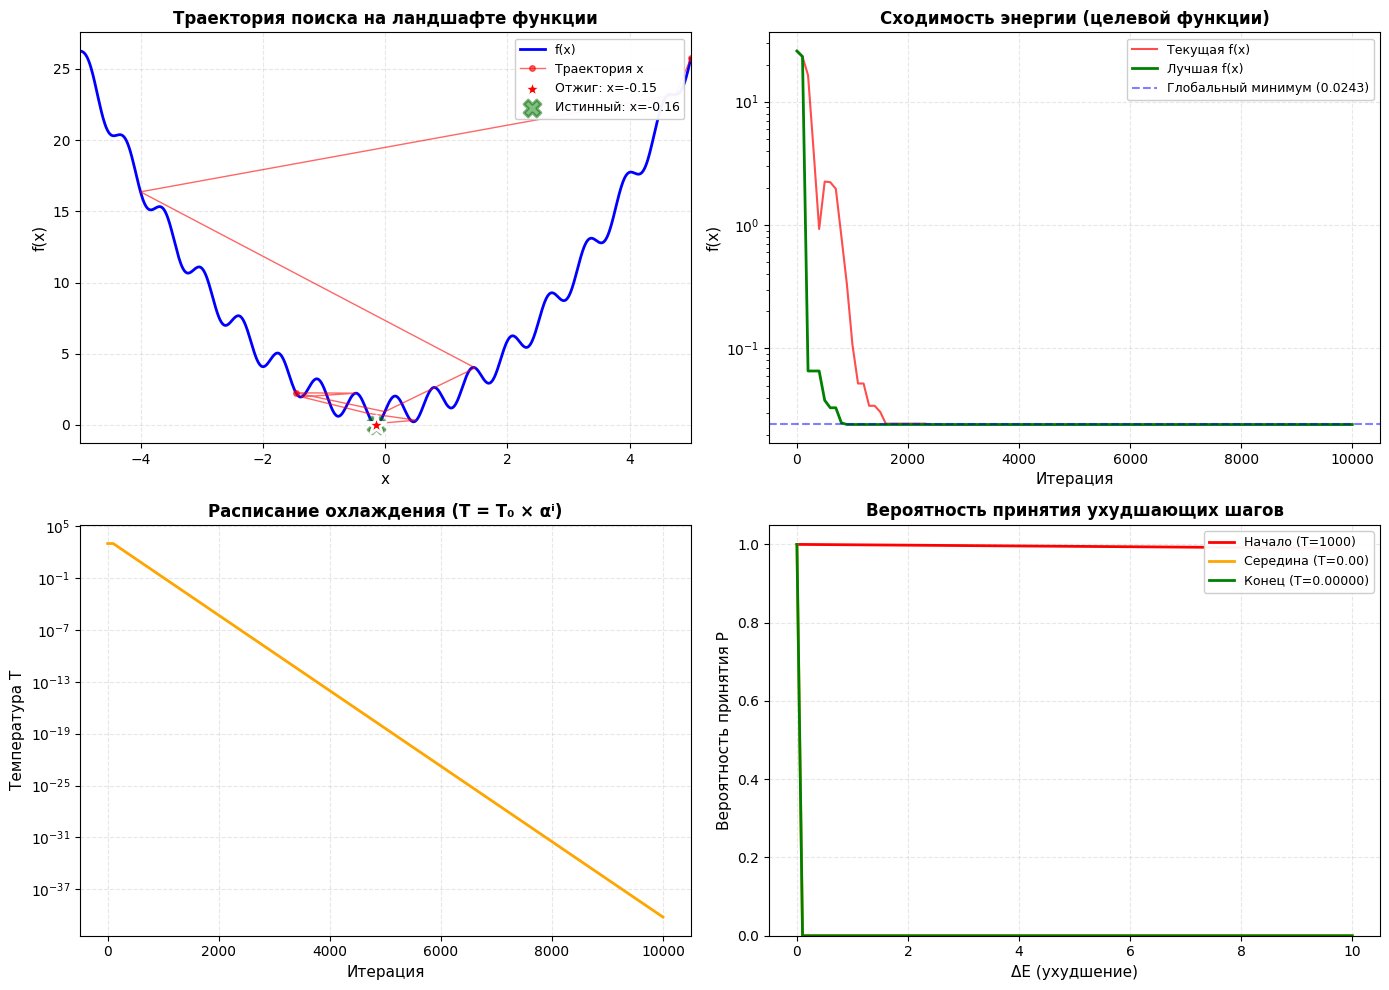

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
import math
import matplotlib.pyplot as plt

# 🎨 Настройка вывода: читаемые числа
np.set_printoptions(precision=5, suppress=True)

# Фиксируем seed для воспроизводимости результатов на лекции
np.random.seed(42)

# ==============================================================================
# 1️⃣ ЦЕЛЕВАЯ ФУНКЦИЯ: Многоэкстремальная
# ==============================================================================
def f(x):
    """
    Целевая функция для минимизации.
    f(x) = x² + sin(10x) + 1

    Особенности:
    • x² — глобальная форма (парабола)
    • sin(10x) — создаёт ~15 локальных минимумов на [-5, 5]
    • Идеально для демонстрации «выпрыгивания» из локальных минимумов
    """
    return x**2 + np.sin(10*x) + 1

# Визуализация функции (для понимания ландшафта)
x_range = np.linspace(-5, 5, 1000)
y_range = f(x_range)
global_min_idx = np.argmin(y_range)
global_min_x = x_range[global_min_idx]
global_min_y = y_range[global_min_idx]

print("🔍 ЦЕЛЕВАЯ ФУНКЦИЯ:")
print(f"   f(x) = x² + sin(10x) + 1")
print(f"   Границы поиска: x ∈ [-5, 5]")
print(f"   Приблизительный глобальный минимум: x ≈ {global_min_x:.4f}, f(x) ≈ {global_min_y:.4f}\n")

# ==============================================================================
# 2️⃣ ПАРАМЕТРЫ АЛГОРИТМА ОТЖИГА
# ==============================================================================
# 🔹 Начальная температура: высокая → много случайных шагов
T_initial = 1000.0

# 🔹 Конечная температура: низкая → почти жадный спуск
T_final = 0.001

# 🔹 Коэффициент охлаждения: насколько уменьшать T каждый шаг
# • 0.99 → медленное охлаждение (больше итераций, лучше поиск)
# • 0.90 → быстрое охлаждение (риск застрять в локальном минимуме)
alpha = 0.99

# 🔹 Начальное состояние: случайная точка
x_initial = 5.0

# 🔹 Максимум итераций
max_iterations = 10000

# 🔹 Размер шага: насколько далеко может прыгнуть соседнее состояние
step_size = 1.0

print("⚙️  ПАРАМЕТРЫ ОТЖИГА:")
print("=" * 50)
print(f"Начальная температура T₀:  {T_initial}")
print(f"Конечная температура Tₙ:  {T_initial * (alpha ** max_iterations):.6f}")
print(f"Коэффициент охлаждения α:  {alpha}")
print(f"Начальное состояние x₀:    {x_initial}")
print(f"Максимум итераций:         {max_iterations}")
print(f"Размер шага:               {step_size}")
print("=" * 50)

# ==============================================================================
# 3️⃣ ОСНОВНОЙ ЦИКЛ АЛГОРИТМА
# ==============================================================================
print("\n🚀 Запуск имитации отжига...")

# Текущее состояние
x = x_initial
current_energy = f(x)

# Лучшее найденное состояние (отдельно от текущего!)
best_x = x
best_energy = current_energy

# История для визуализации
history_x = [x]
history_energy = [current_energy]
history_best = [best_energy]
history_T = [T_initial]
accepted_count = 0  # Счётчик принятых шагов
worse_accepted_count = 0  # Счётчик принятых УХУДШАЮЩИХ шагов

T = T_initial  # Текущая температура

for i in range(max_iterations):
    # 🔹 Шаг 1: Генерация соседнего состояния (случайный прыжок)
    x_new = x + np.random.uniform(-step_size, step_size)

    # Ограничиваем поиск границами (опционально)
    x_new = np.clip(x_new, -5, 5)

    # 🔹 Шаг 2: Вычисление изменения «энергии»
    new_energy = f(x_new)
    delta_E = new_energy - current_energy

    # 🔹 Шаг 3: Решение — принять или отклонить новое состояние
    if delta_E < 0:
        # ✅ Улучшение — всегда принимаем
        accept = True
    else:
        # ⚠️  Ухудшение — принимаем с вероятностью Больцмана
        # P = exp(-ΔE / T)
        # Чем выше T, тем больше вероятность принять ухудшение
        probability = math.exp(-delta_E / T)
        accept = np.random.rand() < probability
        if accept:
            worse_accepted_count += 1

    # 🔹 Шаг 4: Обновление состояния
    if accept:
        x = x_new
        current_energy = new_energy
        accepted_count += 1

        # Обновляем лучшее найденное состояние
        if current_energy < best_energy:
            best_x = x
            best_energy = current_energy

    # 🔹 Шаг 5: Охлаждение (уменьшаем температуру)
    T *= alpha

    # 🔹 Сохраняем историю для визуализации (каждые 100 итераций)
    if i % 100 == 0:
        history_x.append(x)
        history_energy.append(current_energy)
        history_best.append(best_energy)
        history_T.append(T)

print("✅ Отжиг завершён!\n")

# ==============================================================================
# 4️⃣ РЕЗУЛЬТАТЫ
# ==============================================================================
print("📊 РЕЗУЛЬТАТЫ ОТЖИГА:")
print("=" * 50)
print(f"Лучшее найденное x:     {best_x:.5f}")
print(f"Лучшее найденное f(x):  {best_energy:.5f}")
print(f"Истинный минимум:       x ≈ {global_min_x:.5f}, f(x) ≈ {global_min_y:.5f}")
print(f"Отклонение от оптимума: {np.abs(best_x - global_min_x):.5f}")
print(f"Всего итераций:         {max_iterations}")
print(f"Принято шагов:          {accepted_count} ({accepted_count/max_iterations*100:.1f}%)")
print(f"Принято ухудшений:      {worse_accepted_count} ({worse_accepted_count/max_iterations*100:.1f}%)")
print("=" * 50)

# ==============================================================================
# 5️⃣ ВИЗУАЛИЗАЦИЯ
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- График 1: Ландшафт функции + траектория поиска ---
ax1 = axes[0, 0]
ax1.plot(x_range, y_range, 'b-', linewidth=2, label='f(x)')

# Траектория текущего состояния
ax1.plot(history_x, [f(x) for x in history_x], 'r-o', markersize=4,
         linewidth=1, alpha=0.6, label='Траектория x', markevery=5)

# Лучшее найденное решение
ax1.scatter([best_x], [best_energy], c='red', s=200, marker='*',
            edgecolors='white', linewidth=2, label=f'Отжиг: x={best_x:.2f}', zorder=10)

# Истинный минимум (полупрозрачный)
ax1.scatter([global_min_x], [global_min_y], c='green', s=150, marker='X',
            alpha=0.5, edgecolors='darkgreen', linewidth=2,
            label=f'Истинный: x={global_min_x:.2f}', zorder=8)

ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('f(x)', fontsize=11)
ax1.set_title('Траектория поиска на ландшафте функции', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', framealpha=0.95, fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(-5, 5)

# --- График 2: Энергия (целевая функция) по итерациям ---
ax2 = axes[0, 1]
iterations_plot = range(0, max_iterations + 1, 100)
ax2.plot(iterations_plot, history_energy, 'r-', linewidth=1.5, alpha=0.7, label='Текущая f(x)')
ax2.plot(iterations_plot, history_best, 'g-', linewidth=2, label='Лучшая f(x)')
ax2.axhline(y=global_min_y, color='blue', linestyle='--', alpha=0.5,
            label=f'Глобальный минимум ({global_min_y:.4f})')
ax2.set_xlabel('Итерация', fontsize=11)
ax2.set_ylabel('f(x)', fontsize=11)
ax2.set_title('Сходимость энергии (целевой функции)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', framealpha=0.95, fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_yscale('log')  # Логарифмическая шкала для наглядности

# --- График 3: Температура по итерациям ---
ax3 = axes[1, 0]
ax3.plot(iterations_plot, history_T, 'orange', linewidth=2)
ax3.set_xlabel('Итерация', fontsize=11)
ax3.set_ylabel('Температура T', fontsize=11)
ax3.set_title('Расписание охлаждения (T = T₀ × αⁱ)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_yscale('log')  # Логарифмическая шкала для экспоненциального спада

# --- График 4: Вероятность принятия ухудшений ---
ax4 = axes[1, 1]
# Вычисляем вероятность для разного ΔE при разной T
delta_E_range = np.linspace(0, 10, 100)
T_high = T_initial
T_mid = T_initial * (alpha ** 5000)
T_low = T_initial * (alpha ** max_iterations)

ax4.plot(delta_E_range, np.exp(-delta_E_range / T_high), 'r-', linewidth=2,
         label=f'Начало (T={T_high:.0f})')
ax4.plot(delta_E_range, np.exp(-delta_E_range / T_mid), 'orange', linewidth=2,
         label=f'Середина (T={T_mid:.2f})')
ax4.plot(delta_E_range, np.exp(-delta_E_range / T_low), 'green', linewidth=2,
         label=f'Конец (T={T_low:.5f})')

ax4.set_xlabel('ΔE (ухудшение)', fontsize=11)
ax4.set_ylabel('Вероятность принятия P', fontsize=11)
ax4.set_title('Вероятность принятия ухудшающих шагов', fontsize=12, fontweight='bold')
ax4.legend(loc='upper right', framealpha=0.95, fontsize=9)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()